# Figure 3 — orientation

Load free-tensor and refloxide DFT-slab fits, extract optical constants, fit
slab orientation from the free tensor, and render the main and SI figures.

The DFT-slab geometry and spectral traces come from the multi-energy refloxide
``Objective`` pickle. Legacy pyref ``GlobalObjective`` DFT is kept only for MSC
bars until the refloxide refinement beats it on AIC/BIC.


## 1. Load in data


In [21]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyref.fitting as fit
import uncertainties.unumpy as unp
from matplotlib import gridspec, ticker
from matplotlib.collections import LineCollection
from matplotlib.colors import to_rgba
from matplotlib.container import ErrorbarContainer
from matplotlib.legend_handler import HandlerBase
from matplotlib.lines import Line2D
from matplotlib.markers import CARETDOWNBASE, CARETUPBASE
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter
from numpy.polynomial.polynomial import polyfit, polyval
from scipy.optimize import least_squares
from scienceplots import scienceplots
from uncertainties import correlated_values, ufloat, umath

from utils import models_root, read_fit, read_ooc
from utils.helpers.plotting_helper import set_plotting_defaults
from utils.refloxide_view import load_refloxide_fit

plt.style.use(["science", "no-latex"])
set_plotting_defaults()

exp_constrained = read_fit("free/free_en_offset_init_2.pkl", material="znpc")
dft_constrained = read_fit("dft/dft_en_offset_new2.pkl", material="znpc")

REFLOXIDE_FIT_PATH = models_root / "xrr/znpc/refloxide/refit-refloxide.pkl"
if not REFLOXIDE_FIT_PATH.exists():
    raise FileNotFoundError(
        f"missing {REFLOXIDE_FIT_PATH} -- run the save cell in "
        "real_data_fit.ipynb (or refloxide/examples/real_data_repl.py) first"
    )
refloxide_objective = load_refloxide_fit(REFLOXIDE_FIT_PATH)
refloxide_structure = refloxide_objective.model.structure

ooc = read_ooc("dft.csv", material="znpc")
ooc = ooc[(ooc["energy"] > 270) & (ooc["energy"] < 300)]

print(
    f"refloxide: {len(refloxide_objective.varying_parameters())} varying; "
    f"legacy DFT kept for MSC only"
)


refloxide: 101 varying; legacy DFT kept for MSC only


## 2. Extract optical constants


In [22]:
def name_map(s: str):
    key = s.split("_")[0].lower() if "_" in s else s.lower()
    match key:
        case "znpc":
            return "bulk"
        case "contamination":
            return "interface"
        case _:
            return key if key in {"surface", "bulk", "interface"} else s


REFLOXIDE_SLAB_ROLES = {
    "ZnPc_surface": "surface",
    "ZnPc_bulk": "bulk",
    "ZnPc_interface": "interface",
}


def as_ufloat(p):
    if getattr(p, "stderr", None) is None:
        return ufloat(p.value, 0)
    return ufloat(p.value, p.stderr)


def rotate_tensor(xx, zz, ixx, izz, rotation):
    cs = umath.cos(rotation) ** 2
    ss = 1 - cs
    n_xx_r = (xx * (1 + cs) + zz * ss) / 2
    n_zz_r = xx * ss + zz * cs
    n_ixx_r = (ixx * (1 + cs) + izz * ss) / 2
    n_izz_r = ixx * ss + izz * cs
    return n_xx_r, n_zz_r, n_ixx_r, n_izz_r


def n(ooc_df, density, rotation, confidence=1):
    rotation = ufloat(rotation.n, rotation.s * confidence)
    density = ufloat(density.n, density.s * confidence)
    zeros = np.zeros_like(ooc_df["n_xx"].values)
    n_xx = unp.uarray(ooc_df["n_xx"].values, ooc_df["n_xx_err"].values if "n_xx_err" in ooc_df else zeros)
    n_zz = unp.uarray(ooc_df["n_zz"].values, ooc_df["n_zz_err"].values if "n_zz_err" in ooc_df else zeros)
    n_ixx = unp.uarray(ooc_df["n_ixx"].values, ooc_df["n_ixx_err"].values if "n_ixx_err" in ooc_df else zeros)
    n_izz = unp.uarray(ooc_df["n_izz"].values, ooc_df["n_izz_err"].values if "n_izz_err" in ooc_df else zeros)

    n_o, n_e, n_io, n_ie = rotate_tensor(n_xx, n_zz, n_ixx, n_izz, rotation)
    n_o, n_e, n_io, n_ie = n_o * density, n_e * density, n_io * density, n_ie * density
    delta = 2 * n_o + n_e
    beta = 2 * n_io + n_ie
    dichroism = n_io - n_ie
    birefringence = n_o - n_e
    return pd.DataFrame(
        {
            "energy": ooc_df["energy"].values,
            "n_o": unp.nominal_values(n_o),
            "n_o_err": unp.std_devs(n_o),
            "n_e": unp.nominal_values(n_e),
            "n_e_err": unp.std_devs(n_e),
            "n_io": unp.nominal_values(n_io),
            "n_io_err": unp.std_devs(n_io),
            "n_ie": unp.nominal_values(n_ie),
            "n_ie_err": unp.std_devs(n_ie),
            "delta": unp.nominal_values(delta),
            "delta_err": unp.std_devs(delta),
            "beta": unp.nominal_values(beta),
            "beta_err": unp.std_devs(beta),
            "dichroism": unp.nominal_values(dichroism),
            "dichroism_err": unp.std_devs(dichroism),
            "birefringence": unp.nominal_values(birefringence),
            "birefringence_err": unp.std_devs(birefringence),
        }
    )


def extract_free_optical_parameters(objectives):
    params: dict[str, list] = {
        "slab": [],
        "energy": [],
        "delta": [],
        "delta_err": [],
        "beta": [],
        "beta_err": [],
        "dichroism": [],
        "dichroism_err": [],
        "birefringence": [],
        "birefringence_err": [],
        "xx": [],
        "xx_err": [],
        "zz": [],
        "zz_err": [],
        "ixx": [],
        "ixx_err": [],
        "izz": [],
        "izz_err": [],
    }

    for o in objectives:
        if o.model.energy == 250.0:
            continue
        structure = getattr(o.model.structure, "components", o.model.structure)
        for s in structure:
            if not hasattr(s, "sld") or isinstance(s.sld, fit.MaterialSLD):
                continue
            slab = name_map(s.name.split("_")[0].lower())
            xx = as_ufloat(s.sld.xx)
            zz = as_ufloat(s.sld.zz)
            ixx = as_ufloat(s.sld.ixx)
            izz = as_ufloat(s.sld.izz)
            delta = 2 * xx + zz
            beta = 2 * ixx + izz
            dich = ixx - izz
            biref = xx - zz
            params["slab"].append(slab)
            params["energy"].append(o.model.energy)
            params["xx"].append(xx.n)
            params["xx_err"].append(xx.s)
            params["zz"].append(zz.n)
            params["zz_err"].append(zz.s)
            params["ixx"].append(ixx.n)
            params["ixx_err"].append(ixx.s)
            params["izz"].append(izz.n)
            params["izz_err"].append(izz.s)
            params["delta"].append(delta.n)
            params["delta_err"].append(delta.s)
            params["beta"].append(beta.n)
            params["beta_err"].append(beta.s)
            params["dichroism"].append(dich.n)
            params["dichroism_err"].append(dich.s)
            params["birefringence"].append(biref.n)
            params["birefringence_err"].append(biref.s)

    df = pd.DataFrame(params)
    return pd.concat(
        [df[df["slab"] == "surface"], df[df["slab"] == "bulk"], df[df["slab"] == "interface"]]
    )


def extract_refloxide_optical_traces(structure, ooc_df, confidence=1):
    """
    Build per-slab optical traces from a shared refloxide UniTensor stack + OOC.

    Density and rotation are taken from ``structure`` (one value per slab across
    all energies); energy dependence comes only from ``ooc_df``.
    """
    params: dict[str, list] = {
        "slab": [],
        "density": [],
        "rotation": [],
        "rotation_err": [],
        "energy": [],
        "xx": [],
        "xx_err": [],
        "zz": [],
        "zz_err": [],
        "ixx": [],
        "ixx_err": [],
        "izz": [],
        "izz_err": [],
        "delta": [],
        "delta_err": [],
        "beta": [],
        "beta_err": [],
        "dichroism": [],
        "dichroism_err": [],
        "birefringence": [],
        "birefringence_err": [],
    }
    for rx_name, role in REFLOXIDE_SLAB_ROLES.items():
        s = structure.slab(rx_name)
        density = as_ufloat(s.sld.density)
        rotation = as_ufloat(s.sld.rotation)
        index = n(ooc_df, density, rotation, confidence=confidence)
        n_e = len(index)
        params["slab"].extend([role] * n_e)
        params["density"].extend([density] * n_e)
        params["rotation"].extend([rotation] * n_e)
        params["rotation_err"].extend([rotation.s] * n_e)
        params["energy"].extend(index["energy"].to_numpy())
        params["xx"].extend(index["n_o"].to_numpy())
        params["xx_err"].extend(index["n_o_err"].to_numpy())
        params["zz"].extend(index["n_e"].to_numpy())
        params["zz_err"].extend(index["n_e_err"].to_numpy())
        params["ixx"].extend(index["n_io"].to_numpy())
        params["ixx_err"].extend(index["n_io_err"].to_numpy())
        params["izz"].extend(index["n_ie"].to_numpy())
        params["izz_err"].extend(index["n_ie_err"].to_numpy())
        params["delta"].extend(index["delta"].to_numpy())
        params["delta_err"].extend(index["delta_err"].to_numpy())
        params["beta"].extend(index["beta"].to_numpy())
        params["beta_err"].extend(index["beta_err"].to_numpy())
        params["dichroism"].extend(index["dichroism"].to_numpy())
        params["dichroism_err"].extend(index["dichroism_err"].to_numpy())
        params["birefringence"].extend(index["birefringence"].to_numpy())
        params["birefringence_err"].extend(index["birefringence_err"].to_numpy())

    df = pd.DataFrame(params)
    return pd.concat(
        [df[df["slab"] == "surface"], df[df["slab"] == "bulk"], df[df["slab"] == "interface"]]
    )


free_n = extract_free_optical_parameters(exp_constrained.objectives)
dft_n = extract_refloxide_optical_traces(refloxide_structure, ooc, confidence=1)


## 3. Fit orientation


In [23]:
from scipy.optimize import Bounds, least_squares
from uncertainties import correlated_values


def _column_errors(slab_df, col, err_col_fmt):
    err_key = err_col_fmt.format(col=col)
    if err_key in slab_df.columns:
        err = slab_df[err_key].to_numpy(dtype=float)
    else:
        err = np.ones(slab_df[col].shape[0], dtype=float)
    return np.maximum(err, np.finfo(float).eps)


def fit_orientation_from_free(
    free_slab,
    ooc_df,
    dft_slab,
    energy_col="energy",
    xx_col="xx",
    zz_col="zz",
    ixx_col="ixx",
    izz_col="izz",
    err_col_fmt="{col}_err",
):
    """
  Fit slab orientation (gamma, radians) and density to free tensor components.

  Minimizes weighted squared residuals on ixx, izz, xx, and zz. Approximates
  parameter uncertainties from the residual Jacobian at the optimum and
  returns correlated ``ufloat`` values.

  Parameters
  ----------
  free_slab : pandas.DataFrame
      Per-slab free-model tensor components and optional error columns.
  ooc_df : pandas.DataFrame
      Oriented optical constants with columns ``energy``, ``n_ixx``, ``n_izz``,
      ``n_xx``, and ``n_zz``.
  dft_slab : pandas.DataFrame
      DFT slab row supplying initial ``rotation`` and ``density`` (as ``ufloat``).
  energy_col : str, optional
      Photon energy column in ``free_slab``.
  xx_col, zz_col, ixx_col, izz_col : str, optional
      Tensor component columns in ``free_slab``.
  err_col_fmt : str, optional
      Format string for error columns, e.g. ``"{col}_err"``.

  Returns
  -------
  gamma_fit : uncertainties.core.Variable
      Fitted tilt angle (radians) with standard uncertainty.
  density_fit : uncertainties.core.Variable
      Fitted density with standard uncertainty (correlated with ``gamma_fit``).
  result : scipy.optimize.OptimizeResult
      ``least_squares`` result including ``jac`` at the solution.
  cov : numpy.ndarray
      2x2 parameter covariance matrix, scaled by the residual mean square
      ``sum(residuals**2) / dof`` so uncertainties match the weighted fit scatter.
  """

    def model_components(gamma, density):
        energies = free_slab[energy_col].to_numpy()
        ixx = np.interp(energies, ooc_df["energy"], ooc_df["n_ixx"])
        izz = np.interp(energies, ooc_df["energy"], ooc_df["n_izz"])
        xx = np.interp(energies, ooc_df["energy"], ooc_df["n_xx"])
        zz = np.interp(energies, ooc_df["energy"], ooc_df["n_zz"])

        c = np.cos(gamma) ** 2
        s = np.sin(gamma) ** 2

        ixx_model = density * (ixx * (1 + c) + izz * s) / 2
        xx_model = density * (xx * (1 + c) + zz * s) / 2
        izz_model = density * (ixx * s + izz * c)
        zz_model = density * (xx * s + zz * c)

        return ixx_model, izz_model, xx_model, zz_model

    ixx = free_slab[ixx_col].to_numpy(dtype=float)
    izz = free_slab[izz_col].to_numpy(dtype=float)
    xx = free_slab[xx_col].to_numpy(dtype=float)
    zz = free_slab[zz_col].to_numpy(dtype=float)
    ixx_err = _column_errors(free_slab, ixx_col, err_col_fmt)
    izz_err = _column_errors(free_slab, izz_col, err_col_fmt)
    xx_err = _column_errors(free_slab, xx_col, err_col_fmt)
    zz_err = _column_errors(free_slab, zz_col, err_col_fmt)

    def residual_vector(params):
        gamma, density = params
        ixx_model, izz_model, xx_model, zz_model = model_components(gamma, density)
        return np.concatenate(
            [
                (ixx - ixx_model) / ixx_err,
                (izz - izz_model) / izz_err,
                (xx - xx_model) / xx_err,
                (zz - zz_model) / zz_err,
            ]
        )

    gamma0 = dft_slab["rotation"].values[0]
    density0 = dft_slab["density"].values[0]
    x0 = np.array([gamma0.nominal_value, density0.nominal_value], dtype=float)
    bounds = Bounds(
        lb=[
            min(0.0, gamma0.nominal_value - 5 * gamma0.std_dev),
            max(0.0, density0.nominal_value - density0.std_dev),
        ],
        ub=[
            min(np.pi / 2, gamma0.nominal_value + 5 * gamma0.std_dev),
            max(0.0, density0.nominal_value + density0.std_dev),
        ],
        keep_feasible=True,
    )

    result = least_squares(
        residual_vector,
        x0,
        bounds=(bounds.lb, bounds.ub),
        method="trf",
        jac="3-point",
    )

    jtj = result.jac.T @ result.jac
    try:
        cov_unit = np.linalg.inv(jtj)
    except np.linalg.LinAlgError:
        cov_unit = np.full((2, 2), np.nan)

    n_res = int(result.fun.size)
    n_par = int(result.x.size)
    dof = max(n_res - n_par, 1)
    mse = (2.0 * float(result.cost)) / dof
    cov = mse * cov_unit

    gamma_fit, density_fit = correlated_values(result.x, cov)
    return gamma_fit, density_fit, result, cov


slab_results = {}
for slab in free_n["slab"].unique():
    slab_df = free_n[free_n["slab"] == slab]
    dft_slab = dft_n[dft_n["slab"] == slab]
    gamma, density, result, cov = fit_orientation_from_free(slab_df, ooc, dft_slab)
    slab_results[slab] = {
        "gamma": gamma,
        "density": density,
        "result": result,
        "cov": cov,
    }


## 4. Figure 3


surface beta: n=18, IQR(gamma)=4.28 deg, bound=14/18
surface delta: n=18, IQR(gamma)=8.08 deg, bound=12/18
surface: |gamma_beta - gamma_delta| med=43.4 deg, max=52.4 deg
bulk beta: n=18, IQR(gamma)=0.00 deg, bound=15/18
bulk delta: n=18, IQR(gamma)=18.75 deg, bound=13/18
bulk: |gamma_beta - gamma_delta| med=0.0 deg, max=27.6 deg
interface beta: n=18, IQR(gamma)=2.39 deg, bound=2/18
interface delta: n=18, IQR(gamma)=3.59 deg, bound=4/18
interface: |gamma_beta - gamma_delta| med=5.0 deg, max=14.6 deg
refloxide MSC (not plotted until it beats legacy DFT): chi2_nu=6.76, AIC=4900, BIC=5498, N=101
surface birefringence E<283.7: deg=4, n=15, y(283.7)=2.313 x0.001
flagged surface birefringence at 283.70 eV: 0.77 +/- 0.22 (x0.001), window +/-4.5
flagged surface dichroism at 287.00 eV: -6.19 +/- 0.67 (x0.001), window +/-4.5  [off scale]
bulk dichroism E<283.7: deg=12, n=15, y(283.7)=0.526 x0.001
flagged bulk dichroism at 283.70 eV: 0.07 +/- 0.07 (x0.001), window +/-4.5
interface birefringence E<

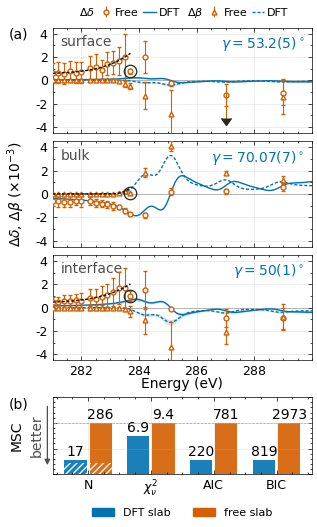

In [25]:
"""
Figure 3 (single PRL column): free per-energy tensor points vs DFT slab model.

Layout
  (a) surface / bulk / interface spectra (birefringence, dichroism) with a
      low-energy guide ending at 283.7 eV
  (b) MSC bars (DFT slab vs free slab)

Requires free_n (free pickle), dft_n (from refloxide_structure + OOC),
slab_results, ooc, and legacy dft_constrained for MSC bars only.
SI full-width companion is the next section.
"""
# Okabe-Ito blue and vermillion. The previous blue/green pair sat too close
# in both hue and luminance to separate at print scale; blue against
# vermillion is the widest separation available and stays distinct under
# deuteranopia and protanopia.
C_DFT = "#0072B2"    # blue
C_FREE = "#D55E00"   # vermillion
C_FREE_FILL = to_rgba(C_FREE, 0.20)

LB, UB = 281.0, 290.0
MAGIC_ANGLE_DEG = np.degrees(np.arcsin(np.sqrt(2 / 3)))
RHO_NOMINAL = 1.61
slab_order = ["surface", "bulk", "interface"]
slab_names = ["surf.", "bulk", "int."]

# Slab encodings for the SI spectra panels, where all three slabs share one
# axis and the model colors are already spent on DFT vs free.
SLAB_MK = {"surface": "o", "bulk": "s", "interface": "^"}
SLAB_LS = {"surface": (0, (1, 1.2)), "bulk": "-", "interface": (0, (3, 1.3))}

# Panel y-bounds are computed per slab from both quantities (traces and free
# points including error bars), symmetric about zero, padded by Y_PAD, and
# clipped at Y_CAP so a single huge pre-edge error bar cannot flatten the
# traces. Bars beyond Y_CAP clip visibly, which is honest.
Y_PAD = 1.10
Y_CAP = 4.5e-3

# Fit bounds for the per-energy (gamma, density) inversion. The SI forest
# axes use exactly these limits, so the displayed window IS the allowed
# parameter space and clipping against it is visible.
GAMMA_FIT_BOUNDS = (0.0, np.pi / 2)          # rad
RHO_FIT_BOUNDS = (1.0, 3.0)                  # g cm^-3

# All three spectra panels share one decade; factor it into the common
# y-label rather than printing a per-panel offset.
BIREF_SCALE = 1e-3

# Pathological per-energy free fits worth calling out, as (energy, column).
# Marked graphically only; the caption carries the explanation, and the
# values are printed to console for the text.
#   bulk 283.7 eV     dichroism collapses toward zero at the jump
#   surface 287.0 eV  dichroism runs off scale (caret, not an on-axis ring)
OUTLIER_FLAGS = {
    "interface": [(283.7, "birefringence")],
    "bulk": [(283.7, "dichroism")],
    "surface": [(283.7, "birefringence"), (287.0, "dichroism")],
}
FLAG_C = "0.15"

E_JUMP = 283.7
TREND_COL = {
    "surface": "birefringence",
    "bulk": "dichroism",
    "interface": "birefringence",
}
TREND_DEGREE = {
    "surface": 4,
    "bulk": 12,
    "interface": 4,
}
C_TREND = "0.05"
DASH_TREND = (0, (2.0, 1.2))

FIG_W, FIG_H = 3.35, 5.8

# ── Per-energy inversion: free tensor -> apparent (gamma, density) ───────────

def _on_fit_bound(gamma_rad, rho, *, gamma_tol=0.001, rho_tol=1e-3):
    """True when the inversion sits on the allowed (gamma, rho) box edge."""
    return bool(
        gamma_rad <= GAMMA_FIT_BOUNDS[0] + gamma_tol
        or gamma_rad >= GAMMA_FIT_BOUNDS[1] - gamma_tol
        or rho <= RHO_FIT_BOUNDS[0] + rho_tol
        or rho >= RHO_FIT_BOUNDS[1] - rho_tol
    )


def _lab_tensor_models(gamma, density, ixx, izz, xx, zz):
    """Return lab-frame beta and delta component models at one energy."""
    c = np.cos(gamma) ** 2
    s = np.sin(gamma) ** 2
    return {
        "ixx": density * (ixx * (1 + c) + izz * s) / 2,
        "izz": density * (ixx * s + izz * c),
        "xx": density * (xx * (1 + c) + zz * s) / 2,
        "zz": density * (xx * s + zz * c),
    }


def _fit_seeds(gamma0, density0):
    """Deterministic multi-start grid anchored on the DFT slab solution."""
    g_mid = 0.5 * (GAMMA_FIT_BOUNDS[0] + GAMMA_FIT_BOUNDS[1])
    r_mid = 0.5 * (RHO_FIT_BOUNDS[0] + RHO_FIT_BOUNDS[1])
    seeds = [
        (gamma0, density0),
        (gamma0, RHO_FIT_BOUNDS[0]),
        (gamma0, RHO_FIT_BOUNDS[1]),
        (GAMMA_FIT_BOUNDS[0], density0),
        (GAMMA_FIT_BOUNDS[1], density0),
        (g_mid, r_mid),
    ]
    uniq: list[tuple[float, float]] = []
    for seed in seeds:
        g, d = seed
        g = float(np.clip(g, *GAMMA_FIT_BOUNDS))
        d = float(np.clip(d, *RHO_FIT_BOUNDS))
        if not any(abs(g - ug) < 1e-6 and abs(d - ud) < 1e-6 for ug, ud in uniq):
            uniq.append((g, d))
    return uniq


def _apparent_gamma_density(row, ooc_df, gamma0, density0, *, components="both"):
    """
    Fit (gamma, density) to a single energy's free tensor components.

    Uses bounded TRF with deterministic multi-start seeds and soft-L1 loss
    so weak-anisotropy energies still return the best box-constrained solution.

    Parameters
    ----------
    components : {"both", "beta", "delta"}
        ``"beta"`` uses only ``ixx``/``izz``, ``"delta"`` only ``xx``/``zz``,
        and ``"both"`` uses all four lab-frame components.
    """
    e = float(row["energy"])
    ixx = float(np.interp(e, ooc_df["energy"], ooc_df["n_ixx"]))
    izz = float(np.interp(e, ooc_df["energy"], ooc_df["n_izz"]))
    xx0 = float(np.interp(e, ooc_df["energy"], ooc_df["n_xx"]))
    zz0 = float(np.interp(e, ooc_df["energy"], ooc_df["n_zz"]))

    if components == "beta":
        keys = ("ixx", "izz")
    elif components == "delta":
        keys = ("xx", "zz")
    elif components == "both":
        keys = ("ixx", "izz", "xx", "zz")
    else:
        raise ValueError(f"unknown components={components!r}")

    obs = np.array([float(row[k]) for k in keys], dtype=float)
    err = np.array(
        [max(abs(float(row.get(f"{k}_err", 0.0))), 1e-12) for k in keys],
        dtype=float,
    )
    if not np.all(np.isfinite(obs)) or not np.all(np.isfinite(err)):
        return None

    def resid(p):
        models = _lab_tensor_models(p[0], p[1], ixx, izz, xx0, zz0)
        model = np.array([models[k] for k in keys], dtype=float)
        r = (obs - model) / err
        if not np.all(np.isfinite(r)):
            return np.full_like(r, 1e6, dtype=float)
        return r

    best = None
    for x0 in _fit_seeds(gamma0, density0):
        try:
            res = least_squares(
                resid,
                x0=np.asarray(x0, dtype=float),
                method="trf",
                bounds=(
                    np.array([GAMMA_FIT_BOUNDS[0], RHO_FIT_BOUNDS[0]], dtype=float),
                    np.array([GAMMA_FIT_BOUNDS[1], RHO_FIT_BOUNDS[1]], dtype=float),
                ),
                loss="soft_l1",
                f_scale=1.0,
                max_nfev=400,
            )
        except Exception:
            continue
        if not np.all(np.isfinite(res.x)):
            continue
        if best is None or res.cost < best.cost:
            best = res

    if best is None:
        return None
    return float(best.x[0]), float(best.x[1])


def per_energy_cloud(slab, ooc_df, gamma0, density0, *, components="both"):
    """
    Apparent gamma (deg), density, and bound flags vs probe energy for one slab.

    Each energy is an independent (gamma, rho) inversion from either beta
    (ixx, izz) or delta (xx, zz) components alone, highlighting the
    gamma-rho degeneracy when the two channels disagree.
    """
    f = free_n[free_n["slab"] == slab]
    f = f[(f["energy"] >= LB) & (f["energy"] <= UB)]
    energies, gammas, dens, bound = [], [], [], []
    for _, row in f.iterrows():
        out = _apparent_gamma_density(
            row, ooc_df, gamma0, density0, components=components,
        )
        if out is None:
            continue
        g, d = out
        energies.append(float(row["energy"]))
        gammas.append(np.degrees(g))
        dens.append(d)
        bound.append(_on_fit_bound(g, d))
    return (
        np.asarray(energies, dtype=float),
        np.asarray(gammas, dtype=float),
        np.asarray(dens, dtype=float),
        np.asarray(bound, dtype=bool),
    )

# ── Low-energy free-point trend (stops at E_JUMP) ────────────────────────────

def _low_energy_trend(slab, column, *, e_cut=E_JUMP, degree=None):
    """
    Fit a weighted polynomial to free tensor points with energy strictly below ``e_cut``.

    Uses inverse-sigma weights from the free-fit uncertainties. The returned
    curve runs from ``max(LB, min energy in the fit set)`` to ``e_cut`` inclusive
    so the dashed guide ends exactly at the discontinuity energy and never
    extrapolates past it. Degree defaults to ``TREND_DEGREE[slab]`` (0 for bulk
    dichroism, which is flat pre-edge; 2 for surface/interface birefringence).

    Parameters
    ----------
    slab : str
        Slab label in ``free_n`` (``surface``, ``bulk``, or ``interface``).
    column : str
        Free-tensor column to fit (``birefringence`` or ``dichroism``).
    e_cut : float
        Exclusive upper bound on fit energies and inclusive end of the plotted
        guide (eV).
    degree : int or None
        Polynomial degree; ``None`` selects ``TREND_DEGREE[slab]``, then clamps
        to at most ``n_points - 1``.

    Returns
    -------
    tuple[np.ndarray, np.ndarray] or None
        ``(energy_grid, model_values)`` on a dense grid up to ``e_cut``, or
        ``None`` when fewer than two points are available.
    """
    f = free_n[free_n["slab"] == slab]
    sub = f[f["energy"] < e_cut]
    if len(sub) < 2:
        return None
    x = sub["energy"].to_numpy(dtype=float)
    y = sub[column].to_numpy(dtype=float)
    err_col = f"{column}_err"
    if err_col in sub.columns:
        sigma = np.maximum(sub[err_col].to_numpy(dtype=float), 1e-12)
    else:
        sigma = np.ones_like(y)
    if degree is None:
        degree = TREND_DEGREE[slab]
    degree = int(min(degree, len(x) - 1))
    coef = polyfit(x - e_cut, y, deg=degree, w=1.0 / sigma)
    e_lo = max(LB, float(np.min(x)))
    e_grid = np.linspace(e_lo, e_cut, 200)
    y_grid = polyval(e_grid - e_cut, coef)
    print(
        f"{slab} {column} E<{e_cut:g}: deg={degree}, "
        f"n={len(x)}, y({e_cut:g})={y_grid[-1] / BIREF_SCALE:.3f} x{BIREF_SCALE:g}"
    )
    return e_grid, y_grid


# ── Forest scalars ───────────────────────────────────────────────────────────

def _pair(value):
    n = value.n if hasattr(value, "n") else float(value)
    s = value.s if hasattr(value, "s") else 0.0
    return float(n), float(s)


def _dft_scalar(slab, col):
    return _pair(dft_n[dft_n["slab"] == slab].iloc[0][col])


g_dft = {s: np.degrees(_dft_scalar(s, "rotation")[0]) for s in slab_order}
g_dft_e = {s: np.degrees(_dft_scalar(s, "rotation")[1]) for s in slab_order}
r_dft = {s: _dft_scalar(s, "density")[0] for s in slab_order}
r_dft_e = {s: _dft_scalar(s, "density")[1] for s in slab_order}

g_free_pt = {s: _pair(slab_results[s]["gamma"]) for s in slab_order}
g_free_pt = {s: (np.degrees(v), np.degrees(e)) for s, (v, e) in g_free_pt.items()}
r_free_pt = {s: _pair(slab_results[s]["density"]) for s in slab_order}

clouds_beta = {"e": {}, "g": {}, "r": {}, "bound": {}}
clouds_delta = {"e": {}, "g": {}, "r": {}, "bound": {}}
for s in slab_order:
    g0 = slab_results[s]["gamma"].nominal_value
    d0 = slab_results[s]["density"].nominal_value
    for channel, store in (("beta", clouds_beta), ("delta", clouds_delta)):
        e, g, r, b = per_energy_cloud(s, ooc, g0, d0, components=channel)
        store["e"][s], store["g"][s], store["r"][s], store["bound"][s] = e, g, r, b
        print(
            f"{s} {channel}: n={g.size}, "
            f"IQR(gamma)={np.subtract(*np.percentile(g, [75, 25])) if g.size else float('nan'):.2f} deg, "
            f"bound={int(b.sum())}/{b.size}"
        )
    g_b = clouds_beta["g"][s]
    g_d = clouds_delta["g"][s]
    if g_b.size and g_d.size and g_b.size == g_d.size:
        split = np.abs(g_b - g_d)
        print(
            f"{s}: |gamma_beta - gamma_delta| med={np.median(split):.1f} deg, "
            f"max={np.max(split):.1f} deg"
        )

# ── Statistics (same machinery as fig3) ──────────────────────────────────────

def model_selection_stats(objective, *, use_logl=True):
    resid = np.asarray(objective.residuals(), dtype=float)
    n = int(resid.size)
    k = len(objective.varying_parameters())
    chi2 = float(np.sum(resid**2))
    nu = max(n - k, 1)
    if use_logl:
        logl = float(objective.logl())
        aic = 2.0 * k - 2.0 * logl
        bic = k * np.log(n) - 2.0 * logl
    else:
        aic = chi2 + 2.0 * k
        bic = chi2 + k * np.log(n)
    return {"chi2": chi2 / nu, "aic": aic, "bic": bic, "N": k, "npoints": n}


# MSC: legacy pyref DFT remains the "DFT slab" bar until refloxide beats it.
stats = {
    "DFT slab": model_selection_stats(dft_constrained),
    "Free tensor": model_selection_stats(exp_constrained),
}
_refloxide_stats = model_selection_stats(refloxide_objective)
print(
    "refloxide MSC (not plotted until it beats legacy DFT): "
    f"chi2_nu={_refloxide_stats['chi2']:.2f}, "
    f"AIC={_refloxide_stats['aic']:.0f}, BIC={_refloxide_stats['bic']:.0f}, "
    f"N={_refloxide_stats['N']}"
)
# stats["DFT slab"]["N"] = 17
# stats["Free tensor"]["N"] = 266
N_CORR = {"DFT slab": 21 * 4, "Free tensor": 21 * 4}

# ── Per-slab spectral y-bounds ───────────────────────────────────────────────

def _panel_bounds(slab, pad=Y_PAD, cap=Y_CAP):
    """Symmetric y-bounds covering biref and dichroism, traces and points."""
    d = dft_n[dft_n["slab"] == slab]
    d = d[(d["energy"] >= LB) & (d["energy"] <= UB)]
    f = free_n[free_n["slab"] == slab]
    f = f[(f["energy"] >= LB) & (f["energy"] <= UB)]
    vals = [
        d["birefringence"].to_numpy(dtype=float),
        d["dichroism"].to_numpy(dtype=float),
        (f["birefringence"].abs() + f["birefringence_err"].abs()).to_numpy(dtype=float),
        (f["dichroism"].abs() + f["dichroism_err"].abs()).to_numpy(dtype=float),
    ]
    if "birefringence_err" in d.columns:
        vals.append(
            (d["birefringence"].abs() + d["birefringence_err"].abs()).to_numpy(dtype=float)
        )
    if "dichroism_err" in d.columns:
        vals.append(
            (d["dichroism"].abs() + d["dichroism_err"].abs()).to_numpy(dtype=float)
        )
    m = pad * max(float(np.max(np.abs(v))) for v in vals if v.size)
    m = min(m, cap)
    return (-m, m)


spec_bounds = {s: _panel_bounds(s) for s in slab_order}

# ── Shared bits ──────────────────────────────────────────────────────────────

emk = dict(mfc="white", mec=C_FREE, mew=1.0, ls="none", ecolor=C_FREE,
           elinewidth=0.8, capsize=1.5, ms=3.5)

# Ticks display value / BIREF_SCALE; the decade lives in the shared label.
_biref_fmt = FuncFormatter(lambda v, _: f"{v / BIREF_SCALE:.0f}")

DASH_DIC = (0, (2.2, 1.4))

leg_handles = [
    Patch(facecolor=C_DFT, edgecolor=C_DFT, label="DFT slab"),
    Patch(facecolor=C_FREE, edgecolor=C_FREE, label="free slab"),
]


def _free_legend_eb(marker, label="Free"):
    data_line = Line2D(
        [], [],
        ls="none",
        marker=marker,
        color=C_FREE,
        mfc="white",
        mec=C_FREE,
        mew=1.0,
        ms=3.5,
    )
    yerr_line = LineCollection(
        [[[0.0, -1.0], [0.0, 1.0]]],
        colors=[C_FREE],
        linewidths=[0.8],
    )
    return ErrorbarContainer(
        (data_line, (), [yerr_line]),
        has_xerr=False,
        has_yerr=True,
        label=label,
    )


class _QtyHandler(HandlerBase):
    def legend_artist(self, legend, orig_handle, fontsize, handlebox):
        handlebox.set_width(0.0)
        return None

ypos = {s: i for i, s in enumerate(slab_order)}


def _flag_outlier(ax, slab, energy, column):
    """
    Mark a pathological per-energy free fit, graphically only.

    Two idioms, chosen automatically and carrying no text, so the panels
    stay readable and the caption does the explaining. A point inside the
    window gets an open ring. A point past the window gets a filled caret
    seated inside the axes with a stub running to it, which reads as "this
    one continues off scale" without the panel rescaling around it.

    Values are printed to console so the magnitudes are available for the
    manuscript text.
    """
    f = free_n[free_n["slab"] == slab]
    if f.empty:
        return
    row = f.iloc[(f["energy"] - energy).abs().argmin()]
    val = float(row[column])
    err_col = f"{column}_err"
    err = abs(float(row[err_col])) if err_col in f.columns else 0.0
    e = float(row["energy"])

    lo, hi = ax.get_ylim()
    span = hi - lo
    top = val + err > hi
    bot = val - err < lo

    print(f"flagged {slab} {column} at {e:.2f} eV: "
          f"{val / BIREF_SCALE:.2f} +/- {err / BIREF_SCALE:.2f} "
          f"(x{BIREF_SCALE:g}), window +/-{hi / BIREF_SCALE:.1f}"
          f"{'  [off scale]' if (top or bot) else ''}")

    if not (top or bot):
        ax.plot(e, val, "o", ms=9, mfc="none", mec=FLAG_C, mew=0.9, zorder=7)
        return

    # Off-scale: caret seated inside the axes (CARETUPBASE draws upward from
    # its anchor, so anchoring inside keeps it clear of the neighbouring
    # panel and the legend), with a stub leading the eye out of range.
    mk = CARETUPBASE if top else CARETDOWNBASE
    anchor = hi - 0.14 * span if top else lo + 0.14 * span
    stub_from = hi - 0.42 * span if top else lo + 0.42 * span
    ax.plot(e, anchor, marker=mk, ms=7, color=FLAG_C, mfc=FLAG_C,
            ls="none", zorder=8)
    ax.plot([e, e], [stub_from, anchor], color=C_FREE, lw=0.8, zorder=6)


def _free_box(ax, data, position, width=0.55):
    ax.boxplot(
        [data], positions=[position], vert=False, widths=width, whis=0.6827,
        showfliers=False, patch_artist=True, manage_ticks=False,
        medianprops=dict(color=C_FREE),
        whiskerprops=dict(color=C_FREE),
        capprops=dict(color=C_FREE),
        boxprops=dict(facecolor=C_FREE_FILL, edgecolor=C_FREE),
    )

# ── Figure ───────────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(FIG_W, FIG_H))
outer = gridspec.GridSpec(
    2, 1, figure=fig, height_ratios=[4.3, 1.0], hspace=0.18,
)
gs_spec = outer[0].subgridspec(3, 1, hspace=0.08)

axS = [fig.add_subplot(gs_spec[i]) for i in range(3)]
for a in axS[:-1]:
    a.sharex(axS[-1])
ax_m = fig.add_subplot(outer[1])


def _spectral(ax, slab, i, last=False):
    d = dft_n[dft_n["slab"] == slab]
    d = d[(d["energy"] >= LB) & (d["energy"] <= UB)].sort_values("energy")
    if "birefringence_err" in d.columns:
        ax.fill_between(d["energy"],
                        d["birefringence"] - d["birefringence_err"],
                        d["birefringence"] + d["birefringence_err"],
                        color=C_DFT, alpha=0.25, lw=0, zorder=2)
    ax.plot(d["energy"], d["birefringence"], "-", color=C_DFT, zorder=3)
    if "dichroism_err" in d.columns:
        ax.fill_between(d["energy"],
                        d["dichroism"] - d["dichroism_err"],
                        d["dichroism"] + d["dichroism_err"],
                        color=C_DFT, alpha=0.18, lw=0, zorder=2)
    ax.plot(d["energy"], d["dichroism"], ls=DASH_DIC, color=C_DFT, zorder=3)

    f = free_n[free_n["slab"] == slab]
    f = f[(f["energy"] >= LB) & (f["energy"] <= UB)]
    ax.errorbar(f["energy"], f["birefringence"], yerr=f["birefringence_err"],
                marker="o", zorder=4, **emk)
    ax.errorbar(f["energy"], f["dichroism"], yerr=f["dichroism_err"],
                marker="^", zorder=4, **emk)

    trend = _low_energy_trend(slab, TREND_COL[slab])
    if trend is not None:
        e_t, y_t = trend
        ax.plot(e_t, y_t, color=C_TREND, ls=DASH_TREND, lw=1.05, zorder=5)

    ax.axhline(0, color="0.6", lw=0.5, zorder=1)
    ax.set_xlim(LB, UB)
    ax.set_xticks([282, 284, 286, 288])

    ax.set_ylim(spec_bounds[slab])
    # Tick step adapts to the panel window: 1e-3 up to ~3e-3 half-range,
    # 2e-3 beyond, so wide panels stay labeled without crowding.
    step = 1e-3 if spec_bounds[slab][1] <= 3.2e-3 else 2e-3
    ax.yaxis.set_major_locator(ticker.MultipleLocator(step))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(step / 2))
    ax.yaxis.set_major_formatter(_biref_fmt)   # no per-panel offset text
    ax.text(0.03, 0.93, slab, transform=ax.transAxes, ha="left", va="top",
            color="0.30")
    gamma = ufloat(g_dft[slab], g_dft_e[slab])
    ax.text(
        0.97, 0.93,
        rf"$\gamma = {gamma:.1uS}^\circ$",
        transform=ax.transAxes, ha="right", va="top", color=C_DFT,
    )
    # Outlier marks last, so they sit above the traces and the ylim is set.
    for e_flag, col_flag in OUTLIER_FLAGS.get(slab, []):
        _flag_outlier(ax, slab, e_flag, col_flag)

    if not last:
        ax.tick_params(labelbottom=False)


for i, s in enumerate(slab_order):
    _spectral(axS[i], s, i, last=(i == 2))
axS[2].set_xlabel(r"Energy (eV)", labelpad=-1)

# Single shared y-label across the three spectra, scale folded in. Centered on
# the middle panel, which sits at the vertical center of the equal-height stack.
axS[1].set_ylabel(r"$\Delta\delta$, $\Delta\beta$ ($\times 10^{-3}$)")
axS[1].yaxis.set_label_coords(-0.1, 0.5)

qty_d = Line2D([], [], label=r"$\Delta\delta$")
qty_b = Line2D([], [], label=r"$\Delta\beta$")
q_handles = [
    qty_d,
    _free_legend_eb("o"),
    Line2D([], [], color=C_DFT, ls="-", label="DFT"),
    qty_b,
    _free_legend_eb("^"),
    Line2D([], [], color=C_DFT, ls=DASH_DIC, label="DFT"),
]
leg_q = axS[0].legend(
    handles=q_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=6,
    frameon=False,
    handlelength=1.15,
    columnspacing=0.4,
    handletextpad=0.25,
    borderpad=0.05,
    handler_map={qty_d: _QtyHandler(), qty_b: _QtyHandler()},
)

# ── MSC bars (carried from fig3) ─────────────────────────────────────────────

METRICS = ["N", r"$\chi^2_\nu$", "AIC", "BIC"]
BAR_W, GROUP_GAP, INTRA_GAP = 0.30, 0.85, 0.04
models = list(stats)
bar_colors = [C_DFT, C_FREE]
mkeys = ["N", "chi2", "aic", "bic"]
gc = np.arange(4) * GROUP_GAP
offs = np.linspace(-(BAR_W + INTRA_GAP) / 2, (BAR_W + INTRA_GAP) / 2, 2)
norms = {mk: max(stats[m][mk] for m in models) for mk in mkeys}
for gi, mk in enumerate(mkeys):
    for bi, (m, col) in enumerate(zip(models, bar_colors)):
        raw = stats[m][mk]
        norm = raw / norms[mk]
        x = gc[gi] + offs[bi]
        if mk == "N":
            corr = N_CORR[m] / norms[mk]
            ax_m.bar(x, corr, BAR_W, color=col, alpha=0.9, lw=0,
                     hatch="/////", edgecolor="white")
            ax_m.bar(x, norm - corr, BAR_W, bottom=corr, color=col, alpha=0.9, lw=0)
            raw -= N_CORR[m]
        else:
            ax_m.bar(x, norm, BAR_W, color=col, alpha=0.9, lw=0)
        ax_m.text(x, norm + 0.02, f"{raw:.1f}" if mk == "chi2" else f"{raw:.0f}",
                  ha="center", va="bottom")
ax_m.set_ylim(0, 1.5)
ax_m.set_xticks(gc)
ax_m.set_xticklabels(METRICS)
ax_m.set_yticklabels([])
ax_m.axhline(1.0, color="0.65", lw=0.5, ls="--")
# add space between MSC label and the plot for the arrow
ax_m.set_ylabel("MSC", labelpad=17)

# Two-entry model legend below the MSC panel.
ax_m.legend(handles=leg_handles, loc="upper center", bbox_to_anchor=(0.5, -0.30),
            ncol=2, frameon=False)

# "lower is better" arrow in the left margin.
ax_m.annotate("", xy=(-0.02, 0.12), xytext=(-0.02, 0.88),
              xycoords="axes fraction", textcoords="axes fraction",
              arrowprops=dict(arrowstyle="-|>", color="0.3", lw=0.9,
                              shrinkA=0, shrinkB=0, mutation_scale=8),
              annotation_clip=False)
ax_m.text(-0.06, 0.5, "better", transform=ax_m.transAxes, rotation=90,
          ha="center", va="center", color="0.3")

# ── Panel letters ────────────────────────────────────────────────────────────

axS[0].text(-0.17, 1.0, "(a)", transform=axS[0].transAxes, va="top", ha="left")
ax_m.text(-0.17, 1.0, "(b)", transform=ax_m.transAxes, va="top", ha="left")

fig.savefig("FIG3.pdf", dpi=600, bbox_inches="tight", transparent=True)
fig.savefig("FIG3.png", dpi=600, bbox_inches="tight", transparent=True)
plt.show()


## 5. SI figure

Full-width three-column SI: (a) β, (b) δ, (c) per-energy γ (left) and ρ
(right twin) with DFT slab lines and uncertainty bands.


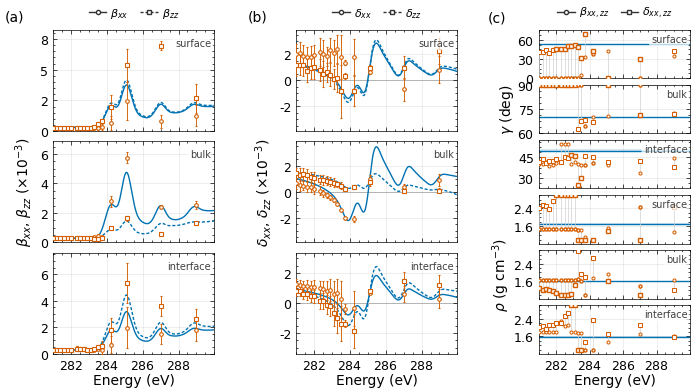

In [17]:
# SI figure, full text width: (a) beta | (b) delta | (c) gamma / rho stacked

FIG_W_FULL = 7.0

SI_BETA_COLS = ("ixx", "izz")
SI_DELTA_COLS = ("xx", "zz")
SI_OPT_LABEL = {
    "xx": r"$\delta_{xx}$",
    "zz": r"$\delta_{zz}$",
    "ixx": r"$\beta_{xx}$",
    "izz": r"$\beta_{zz}$",
}
SI_OPT_LS = {
    "xx": "-",
    "zz": DASH_DIC,
    "ixx": "-",
    "izz": DASH_DIC,
}
SI_OPT_MK = {
    "xx": "o",
    "zz": "s",
    "ixx": "o",
    "izz": "s",
}

DFT_BAND_SCALE = 1.0


def make_si_forest_figure_fullwidth(savename="SI12.png"):
    """
    Export the full-text-width SI figure as three side-by-side panels.

    (a) beta_xx / beta_zz per slab (left column).
    (b) delta_xx / delta_zz per slab (middle column).
    (c) six thin axes: gamma then density for all three slabs. At each energy,
    beta-only and delta-only inversions independently recover (gamma, rho);
    circles vs squares contrast that split. Vertical guides connect the two
    solutions at the same energy; filled markers flag bound hits in the
    admissible box. DFT slab axhline + band is the shared reference.

    Parameters
    ----------
    savename : str
        Output PNG path; a PDF with the same stem is written alongside.
    """
    fig = plt.figure(figsize=(FIG_W_FULL, 4.1))
    outer = gridspec.GridSpec(
        1, 3, figure=fig, width_ratios=[1.12, 1.12, 1.05], wspace=0.52,
    )
    gs_a = outer[0].subgridspec(3, 1, hspace=0.10)
    gs_b = outer[1].subgridspec(3, 1, hspace=0.10)
    gs_c = outer[2].subgridspec(6, 1, hspace=0.14)

    ax_a = [fig.add_subplot(gs_a[i]) for i in range(3)]
    ax_b = [fig.add_subplot(gs_b[i]) for i in range(3)]
    share_c = None
    ax_c_g, ax_c_r = [], []
    for i in range(3):
        ax_g = fig.add_subplot(gs_c[i], sharex=share_c)
        if share_c is None:
            share_c = ax_g
        ax_c_g.append(ax_g)
    for i in range(3):
        ax_c_r.append(fig.add_subplot(gs_c[i + 3], sharex=share_c))
    for group in (ax_a, ax_b):
        for a in group[:-1]:
            a.sharex(group[-1])

    def _tag_slab(ax, slab):
        ax.text(
            0.98, 0.92, slab, transform=ax.transAxes,
            ha="right", va="top", color="0.25", fontsize=7,
            bbox=dict(
                boxstyle="round,pad=0.22",
                facecolor=(1.0, 1.0, 1.0, 0.72),
                edgecolor="none",
            ),
            clip_on=True,
            zorder=10,
        )

    def _param_ylim(values, ref, ref_err, *, lo_cap, hi_cap, min_span):
        vals = np.asarray(values, dtype=float)
        ext = [ref - ref_err, ref + ref_err]
        if vals.size:
            ext.extend([float(np.min(vals)), float(np.max(vals))])
        lo, hi = min(ext), max(ext)
        mid = 0.5 * (lo + hi)
        span = max(hi - lo, min_span) * 1.18
        lo, hi = mid - 0.5 * span, mid + 0.5 * span
        return max(lo, lo_cap), min(hi, hi_cap)

    def _slab_opt_bounds(slab, cols, pad=1.12):
        d = dft_n[dft_n["slab"] == slab]
        d = d[(d["energy"] >= LB) & (d["energy"] <= UB)]
        f = free_n[free_n["slab"] == slab]
        f = f[(f["energy"] >= LB) & (f["energy"] <= UB)]
        extrema = []
        for col in cols:
            err = f"{col}_err"
            for frame in (d, f):
                y = frame[col].to_numpy(dtype=float)
                if err in frame.columns:
                    e = frame[err].to_numpy(dtype=float)
                    extrema.append(np.max(np.abs(y) + np.abs(e)))
                elif y.size:
                    extrema.append(float(np.max(np.abs(y))))
        m = pad * max(extrema) if extrema else 1e-3
        if not np.isfinite(m) or m <= 0:
            m = 1e-3
        if "ixx" in cols or "izz" in cols:
            return (0.0, m)
        return (-m, m)

    def _optical_slab(ax, slab, cols, last, *, ylabel=None):
        d = dft_n[dft_n["slab"] == slab]
        d = d[(d["energy"] >= LB) & (d["energy"] <= UB)].sort_values("energy")
        f = free_n[free_n["slab"] == slab]
        f = f[(f["energy"] >= LB) & (f["energy"] <= UB)]
        for col in cols:
            ax.plot(
                d["energy"], d[col],
                ls=SI_OPT_LS[col], color=C_DFT, lw=1.0, zorder=3,
            )
            err_col = f"{col}_err"
            ax.errorbar(
                f["energy"], f[col],
                yerr=f[err_col] if err_col in f.columns else None,
                marker=SI_OPT_MK[col], ms=2.6, mfc="white", mec=C_FREE,
                mew=0.8, ls="none", ecolor=C_FREE, elinewidth=0.65,
                capsize=1.0, zorder=4,
            )
        ax.axhline(0, color="0.6", lw=0.5, zorder=1)
        ax.set_xlim(LB, UB)
        ax.set_xticks([282, 284, 286, 288])
        lo, hi = _slab_opt_bounds(slab, cols)
        ax.set_ylim(lo, hi)
        ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=4, prune=None))
        ax.yaxis.set_major_formatter(_biref_fmt)
        _tag_slab(ax, slab)
        if ylabel is not None:
            ax.set_ylabel(ylabel)
        if not last:
            ax.tick_params(labelbottom=False)

    def _scalar_panel(
        ax,
        series,
        y0,
        ye,
        *,
        ylim,
        last,
        ylabel=None,
        slab_label=None,
    ):
        ax.axhspan(y0 - ye, y0 + ye, color=C_DFT, alpha=0.16, lw=0, zorder=1)
        ax.axhline(y0, color=C_DFT, ls="-", lw=1.0, zorder=2)
        by_energy = {}
        for energy, y, marker, bound in series:
            if not energy.size:
                continue
            for e, val, hit in zip(energy, y, bound):
                by_energy.setdefault(float(e), []).append((float(val), marker, bool(hit)))
        for e, pts in by_energy.items():
            if len(pts) >= 2:
                ys = [p[0] for p in pts]
                ax.plot(
                    [e, e], [min(ys), max(ys)], color="0.82", lw=0.5,
                    solid_capstyle="round", zorder=3,
                )
            for val, marker, hit in pts:
                ax.plot(
                    [e], [val], ls="none", marker=marker, ms=2.2,
                    mfc="white", mec=C_FREE, mew=1.0 if hit else 0.75, zorder=5,
                )
        ax.set_xlim(LB, UB)
        ax.set_xticks([282, 284, 286, 288])
        ax.set_ylim(*ylim)
        ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=3, prune=None))
        if slab_label is not None:
            _tag_slab(ax, slab_label)
        if ylabel is not None:
            ax.set_ylabel(ylabel, labelpad=1)
        if not last:
            ax.tick_params(labelbottom=False)

    for i, s in enumerate(slab_order):
        _optical_slab(
            ax_a[i], s, SI_BETA_COLS, last=(i == 2),
            ylabel=(r"$\beta_{xx}$, $\beta_{zz}$ ($\times 10^{-3}$)" if i == 1 else None),
        )
        _optical_slab(
            ax_b[i], s, SI_DELTA_COLS, last=(i == 2),
            ylabel=(r"$\delta_{xx}$, $\delta_{zz}$ ($\times 10^{-3}$)" if i == 1 else None),
        )
        e_b = np.asarray(clouds_beta["e"][s], dtype=float)
        g_b = np.asarray(clouds_beta["g"][s], dtype=float)
        r_b = np.asarray(clouds_beta["r"][s], dtype=float)
        b_b = np.asarray(clouds_beta["bound"][s], dtype=bool)
        e_d = np.asarray(clouds_delta["e"][s], dtype=float)
        g_d = np.asarray(clouds_delta["g"][s], dtype=float)
        r_d = np.asarray(clouds_delta["r"][s], dtype=float)
        b_d = np.asarray(clouds_delta["bound"][s], dtype=bool)
        g0, ge = g_dft[s], g_dft_e[s] * DFT_BAND_SCALE
        r0, re = r_dft[s], r_dft_e[s] * DFT_BAND_SCALE
        g_vals = np.concatenate([g_b, g_d]) if g_b.size or g_d.size else np.array([])
        r_vals = np.concatenate([r_b, r_d]) if r_b.size or r_d.size else np.array([])
        g_lo, g_hi = _param_ylim(
            g_vals, g0, ge, lo_cap=0.0, hi_cap=90.0, min_span=12.0,
        )
        r_lo, r_hi = _param_ylim(
            r_vals, r0, re, lo_cap=0.8, hi_cap=3.0, min_span=0.35,
        )
        _scalar_panel(
            ax_c_g[i],
            (
                (e_b, g_b, "o", b_b),
                (e_d, g_d, "s", b_d),
            ),
            g0, ge, ylim=(g_lo, g_hi), last=False,
            ylabel=(r"$\gamma$ (deg)" if i == 1 else None),
            slab_label=s,
        )
        _scalar_panel(
            ax_c_r[i],
            (
                (e_b, r_b, "o", b_b),
                (e_d, r_d, "s", b_d),
            ),
            r0, re, ylim=(r_lo, r_hi), last=(i == 2),
            ylabel=(r"$\rho$ (g cm$^{-3}$)" if i == 1 else None),
            slab_label=s,
        )
    ax_a[2].set_xlabel(r"Energy (eV)", labelpad=1)
    ax_b[2].set_xlabel(r"Energy (eV)", labelpad=1)
    ax_c_r[2].set_xlabel(r"Energy (eV)", labelpad=1)
    for ax in ax_c_g:
        ax.tick_params(labelbottom=False)

    beta_h = [
        Line2D(
            [], [], color="0.2", ls=SI_OPT_LS[c], marker=SI_OPT_MK[c],
            mfc="white", ms=3, label=SI_OPT_LABEL[c],
        )
        for c in SI_BETA_COLS
    ]
    delta_h = [
        Line2D(
            [], [], color="0.2", ls=SI_OPT_LS[c], marker=SI_OPT_MK[c],
            mfc="white", ms=3, label=SI_OPT_LABEL[c],
        )
        for c in SI_DELTA_COLS
    ]
    orient_h = [
        Line2D(
            [], [], color="0.2", ls="-", marker="o",
            mfc="white", ms=3, label=r"$\beta_{xx,zz}$",
        ),
        Line2D(
            [], [], color="0.2", ls="-", marker="s",
            mfc="white", ms=3, label=r"$\delta_{xx,zz}$",
        ),
    ]
    leg_kw_ab = dict(
        loc="lower center", bbox_to_anchor=(0.5, 1.03),
        ncol=2, frameon=False, handlelength=1.6, columnspacing=1.0,
        handletextpad=0.35, borderpad=0.1,
    )
    leg_kw_c = dict(
        loc="lower center", bbox_to_anchor=(0.5, 1.06),
        ncol=2, frameon=False, handlelength=1.6, columnspacing=1.0,
        handletextpad=0.35, borderpad=0.1,
    )
    ax_a[0].legend(handles=beta_h, **leg_kw_ab)
    ax_b[0].legend(handles=delta_h, **leg_kw_ab)
    ax_c_g[0].legend(handles=orient_h, **leg_kw_c)

    ax_a[0].text(-0.30, 1.06, "(a)", transform=ax_a[0].transAxes, va="bottom", ha="left")
    ax_b[0].text(-0.30, 1.06, "(b)", transform=ax_b[0].transAxes, va="bottom", ha="left")
    ax_c_g[0].text(-0.34, 1.10, "(c)", transform=ax_c_g[0].transAxes, va="bottom", ha="left")

    fig.subplots_adjust(left=0.08, right=0.99, top=0.90, bottom=0.11)

    fig.savefig(savename, dpi=600, bbox_inches="tight", transparent=True)
    fig.savefig(
        savename.replace(".png", ".pdf"), dpi=600,
        bbox_inches="tight", transparent=True,
    )
    plt.show()


make_si_forest_figure_fullwidth()
